# YOLO26l — Building Defect Detection

End-to-end Colab notebook that:
1. Downloads 6 Roboflow datasets,
2. Remaps their heterogeneous classes into 4 unified classes (`crack`, `water_leakage`, `electrical_fault`, `mold`),
3. Merges everything into one YOLO-format dataset,
4. Runs EDA (class distribution + sample grids),
5. Applies Albumentations augmentation on the **training split only** (3× multiplier),
6. Trains **YOLO26l** for 100 epochs,
7. Evaluates on the test split,
8. Downloads `best.pt`.

**Runtime**: designed for Google Colab with a T4 GPU. The only manual step is pasting your Roboflow API key when prompted in Cell 2.

**Tip**: if the Colab session disconnects during training, re-run cells 1–2 to restore state, then use the commented “resume” cell after the training cell.

## 0. Install dependencies

In [1]:
!pip install -q ultralytics roboflow albumentations pyyaml seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 123.1 MB/s eta 0:00:00


## 1. Imports, seeds, GPU check

In [2]:
import os
import shutil
import random
import getpass
from pathlib import Path
from collections import defaultdict

import yaml
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import albumentations as A
from roboflow import Roboflow
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("GPU info:")
!nvidia-smi -L

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GPU info:
GPU 0: Tesla T4 (UUID: GPU-aad795ed-f991-d4f2-cae7-7b20a304f7e0)


## 2. Configuration

Paste your Roboflow API key when prompted. Nothing else needs to be edited.

In [ ]:
import os
API_KEY = os.environ.get("ROBOFLOW_API_KEY") or getpass.getpass("Enter your Roboflow API key: ")

# (workspace, project, version, short_id)
# short_id is used as a filename prefix when merging, to avoid collisions.
DATASET_SPECS = [
    ("israas-workspace-icijh", "wall-defects-final", 1, "d1"),
    ("tatung-university-wmt7l", "wall-crack-detection-l0iit", 1, "d2"),
    ("water-leak-hwh4x", "water-leakage-ayy4s", 1, "d4"),
    ("electrical-hazard-zcack", "electrical-hazards", 1, "d5"),
    ("dissertationproject", "mould-detection-aaron", 1, "d6"),
]

UNIFIED_CLASSES = ["crack", "water_leakage", "electrical_fault", "mold"]
CLASS_TO_IDX = {c: i for i, c in enumerate(UNIFIED_CLASSES)}

# Class remapping: unified_class -> list of original-dataset names.
# d2 used size-based labels ("large", "small", "2") instead of type labels —
# all are cracks, so they're now recovered here.
REMAP = {
    "crack":            ["crack", "wall-crack", "major crack", "minor crack",
                         "stairstep_crack", "large", "small", "2"],
    "water_leakage":    ["standing water", "water_seepage", "stain", "leakage", "moisture"],
    "electrical_fault": ["damage wire", "burned socket", "overloaded socket"],
    "mold":             ["mould", "mold"],
}

# Case-insensitive + whitespace-trimmed inverse lookup:
#   normalized_original_name -> unified_class_id
ORIG_TO_UNIFIED = {}
for unified, originals in REMAP.items():
    for orig in originals:
        ORIG_TO_UNIFIED[orig.strip().lower()] = CLASS_TO_IDX[unified]

RAW_DIR     = Path("/content/raw_datasets")
UNIFIED_DIR = Path("/content/unified_dataset")
RUNS_DIR    = Path("/content/runs")

IMG_SIZE        = 640   # confirmed 640×640 from Roboflow export (~54 KB avg); upsampling to 1280 gives no gain
EPOCHS          = 150   # extra 50 vs original to let cosine LR decay fully
BATCH           = 192   # yolo26l is ~50% heavier than m; safe on H100 80 GB
AUG_MULTIPLIER  = 3     # Albumentations copies per training image

RAW_DIR.mkdir(parents=True, exist_ok=True)
UNIFIED_DIR.mkdir(parents=True, exist_ok=True)
RUNS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Unified classes: {UNIFIED_CLASSES}")
print(f"Remap lookup size: {len(ORIG_TO_UNIFIED)} original names")

## 3. Download all 6 datasets from Roboflow

In [16]:
rf = Roboflow(api_key=API_KEY)

for workspace, project_name, version, short_id in DATASET_SPECS:
    target = RAW_DIR / short_id
    if target.exists() and any(target.iterdir()):
        print(f"[{short_id}] Already downloaded at {target}, skipping.")
        continue
    print(f"[{short_id}] Downloading {workspace}/{project_name}/v{version} ...")
    try:
        project = rf.workspace(workspace).project(project_name)

        # Auto-detect latest version if v1 not found
        try:
            ver = project.version(version)
        except RuntimeError:
            versions = project.get_version_information()
            latest = versions[-1]["id"].split("/")[-1]
            print(f"  v{version} not found — using latest version: v{latest}")
            ver = project.version(int(latest))

        ver.download("yolov8", location=str(target))
        for split in ("train", "valid", "test"):
            img_dir = target / split / "images"
            n = len(list(img_dir.glob("*"))) if img_dir.exists() else 0
            print(f"    {split}: {n} images")
    except Exception as e:
        print(f"  !! FAILED [{short_id}]: {e}")
        print(f"     Skipping — will not be included in merged dataset.")

[d1] Already downloaded at /content/raw_datasets/d1, skipping.
[d2] Already downloaded at /content/raw_datasets/d2, skipping.
[d4] Already downloaded at /content/raw_datasets/d4, skipping.
[d5] Already downloaded at /content/raw_datasets/d5, skipping.
[d6] Already downloaded at /content/raw_datasets/d6, skipping.


## 4. Class audit

Every original class from each dataset is printed with its mapping target. Anything flagged `UNMAPPED` will be dropped during merge (its image is still retained as background per our configuration).

In [17]:
print("=" * 80)
print("CLASS AUDIT")
print("=" * 80)

dataset_classes = {}  # short_id -> [class_name_by_index]

for _, _, _, short_id in DATASET_SPECS:
    data_yaml_path = RAW_DIR / short_id / "data.yaml"
    with open(data_yaml_path) as f:
        meta = yaml.safe_load(f)
    classes = meta["names"]
    # Some Roboflow exports use a dict form {0: 'name', 1: 'name'}.
    if isinstance(classes, dict):
        classes = [classes[i] for i in sorted(classes.keys())]
    dataset_classes[short_id] = classes

    mapped = 0
    print(f"\n[{short_id}] {len(classes)} classes:")
    for idx, name in enumerate(classes):
        key = name.strip().lower()
        if key in ORIG_TO_UNIFIED:
            target_name = UNIFIED_CLASSES[ORIG_TO_UNIFIED[key]]
            print(f"    {idx:2d}: {name:<32s} -> {target_name}")
            mapped += 1
        else:
            print(f"    {idx:2d}: {name:<32s} -> UNMAPPED (dropped)")
    if mapped == 0:
        print(f"    !! WARNING: 0 classes from {short_id} match the remap.")
        print(f"       Its images will be kept as background only.")

CLASS AUDIT

[d1] 3 classes:
     0: crack                            -> crack
     1: moisture                         -> water_leakage
     2: mold                             -> mold

[d2] 4 classes:
     0: 2                                -> UNMAPPED (dropped)
     1: large                            -> UNMAPPED (dropped)
     2: small                            -> UNMAPPED (dropped)
     3: wall-crack                       -> crack

[d4] 1 classes:
     0: Standing Water                   -> water_leakage

[d5] 4 classes:
     0: -                                -> UNMAPPED (dropped)
     1: burned socket                    -> electrical_fault
     2: damage wire                      -> electrical_fault
     3: overloaded socket                -> electrical_fault

[d6] 1 classes:
     0: mould                            -> mold


## 5. Merge datasets with remapping

- Images are copied with a `{short_id}_` prefix to prevent filename collisions across datasets.
- Labels are rewritten with the unified class indices (0–3).
- Label lines whose class is not in the remap are silently dropped.
- If an image ends up with zero labels after remapping, an **empty label file** is written (YOLO treats it as background).

In [18]:
# Create unified layout
for split in ("train", "val", "test"):
    (UNIFIED_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (UNIFIED_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

# Roboflow uses 'valid'; Ultralytics expects 'val'. Map during copy.
SPLIT_MAP = {"train": "train", "valid": "val", "test": "test"}

merge_stats = defaultdict(lambda: defaultdict(int))  # [split][class_name] = count

for _, _, _, short_id in DATASET_SPECS:
    classes = dataset_classes[short_id]
    for src_split, dst_split in SPLIT_MAP.items():
        src_img_dir = RAW_DIR / short_id / src_split / "images"
        src_lbl_dir = RAW_DIR / short_id / src_split / "labels"
        if not src_img_dir.exists():
            continue
        dst_img_dir = UNIFIED_DIR / "images" / dst_split
        dst_lbl_dir = UNIFIED_DIR / "labels" / dst_split

        for img_path in src_img_dir.iterdir():
            if not img_path.is_file():
                continue
            new_name = f"{short_id}_{img_path.name}"
            dst_img = dst_img_dir / new_name
            dst_lbl = dst_lbl_dir / f"{Path(new_name).stem}.txt"
            shutil.copy2(img_path, dst_img)

            new_lines = []
            src_lbl = src_lbl_dir / f"{img_path.stem}.txt"
            if src_lbl.exists():
                with open(src_lbl) as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) < 5:
                            continue
                        try:
                            old_id = int(float(parts[0]))
                        except ValueError:
                            continue
                        if old_id < 0 or old_id >= len(classes):
                            continue
                        orig_name = classes[old_id].strip().lower()
                        if orig_name not in ORIG_TO_UNIFIED:
                            continue
                        new_id = ORIG_TO_UNIFIED[orig_name]
                        new_lines.append(f"{new_id} {' '.join(parts[1:5])}")
                        merge_stats[dst_split][UNIFIED_CLASSES[new_id]] += 1
            # Write label file (empty -> background image)
            with open(dst_lbl, "w") as f:
                f.write("\n".join(new_lines))

print("Merge complete.\n")
for split in ("train", "val", "test"):
    n_img = len(list((UNIFIED_DIR / "images" / split).glob("*")))
    print(f"  {split:>5s}: {n_img} images | class counts = {dict(merge_stats[split])}")

Merge complete.

  train: 18581 images | class counts = {'crack': 5906, 'mold': 11960, 'water_leakage': 5432, 'electrical_fault': 6657}
    val: 3803 images | class counts = {'mold': 2218, 'crack': 335, 'water_leakage': 2267, 'electrical_fault': 1920}
   test: 2207 images | class counts = {'mold': 2059, 'crack': 418, 'water_leakage': 604, 'electrical_fault': 921}


## 6. Write unified `data.yaml`

In [19]:
data_yaml = {
    "path":  str(UNIFIED_DIR),
    "train": "images/train",
    "val":   "images/val",
    "test":  "images/test",
    "nc":    len(UNIFIED_CLASSES),
    "names": UNIFIED_CLASSES,
}
data_yaml_path = UNIFIED_DIR / "data.yaml"
with open(data_yaml_path, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print(f"Wrote {data_yaml_path}\n")
print(open(data_yaml_path).read())

Wrote /content/unified_dataset/data.yaml

path: /content/unified_dataset
train: images/train
val: images/val
test: images/test
nc: 4
names:
- crack
- water_leakage
- electrical_fault
- mold



## 7. EDA

### 7a. Class distribution per split

Per-split instance counts:
  train: {'crack': 16024, 'water_leakage': 21697, 'electrical_fault': 26617, 'mold': 40807}
    val: {'crack': 335, 'water_leakage': 2267, 'electrical_fault': 1920, 'mold': 2218}
   test: {'crack': 418, 'water_leakage': 604, 'electrical_fault': 921, 'mold': 2059}


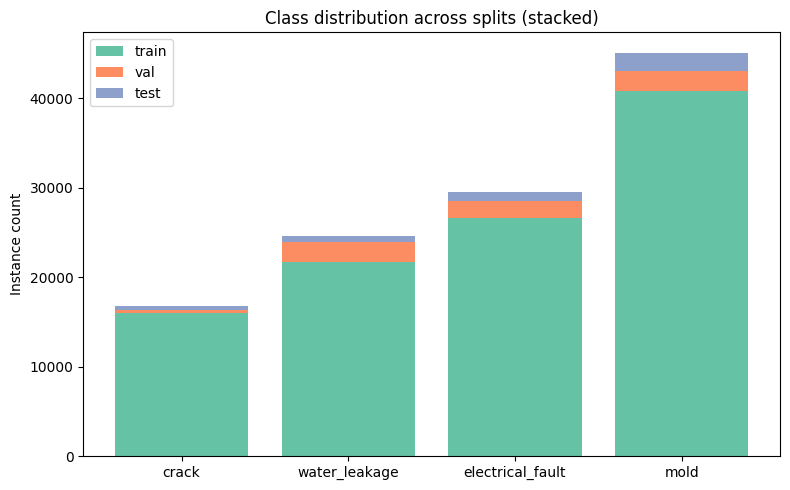

In [26]:
def count_classes(split):
    counts = {c: 0 for c in UNIFIED_CLASSES}
    for lbl in (UNIFIED_DIR / "labels" / split).glob("*.txt"):
        with open(lbl) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    counts[UNIFIED_CLASSES[int(float(parts[0]))]] += 1
    return counts

split_counts = {s: count_classes(s) for s in ("train", "val", "test")}
print("Per-split instance counts:")
for s, counts in split_counts.items():
    print(f"  {s:>5s}: {counts}")

fig, ax = plt.subplots(figsize=(8, 5))
bottom = np.zeros(len(UNIFIED_CLASSES))
palette = sns.color_palette("Set2", n_colors=3)
for color, split in zip(palette, ("train", "val", "test")):
    vals = np.array([split_counts[split][c] for c in UNIFIED_CLASSES])
    ax.bar(UNIFIED_CLASSES, vals, bottom=bottom, label=split, color=color)
    bottom += vals
ax.set_ylabel("Instance count")
ax.set_title("Class distribution across splits (stacked)")
ax.legend()
plt.tight_layout()
plt.show()

### 7b. Per-dataset contribution to each class (train split)

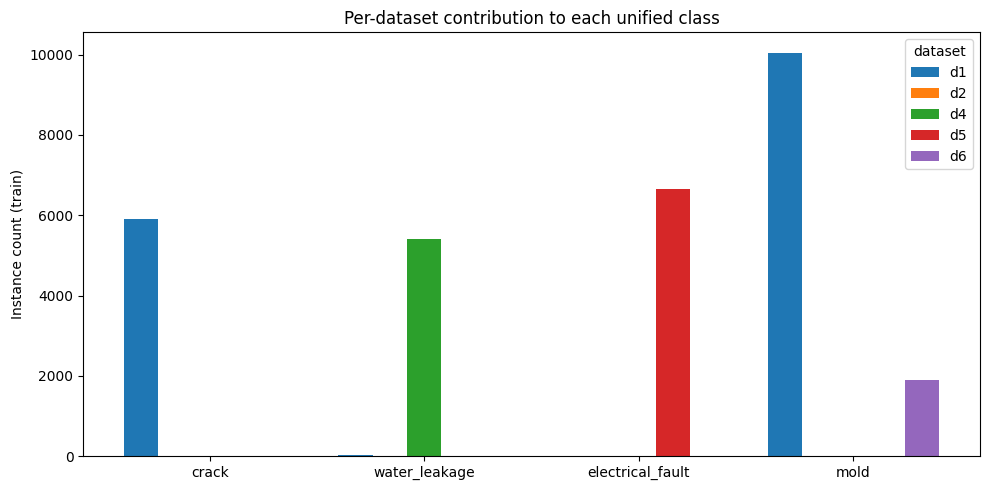

In [21]:
contribution = defaultdict(lambda: {c: 0 for c in UNIFIED_CLASSES})
for lbl in (UNIFIED_DIR / "labels" / "train").glob("*.txt"):
    sid = lbl.stem.split("_")[0]
    with open(lbl) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                contribution[sid][UNIFIED_CLASSES[int(float(parts[0]))]] += 1

short_ids = sorted(contribution.keys())
x = np.arange(len(UNIFIED_CLASSES))
width = 0.8 / max(len(short_ids), 1)
fig, ax = plt.subplots(figsize=(10, 5))
for i, sid in enumerate(short_ids):
    vals = [contribution[sid][c] for c in UNIFIED_CLASSES]
    ax.bar(x + i * width, vals, width, label=sid)
ax.set_xticks(x + width * (len(short_ids) - 1) / 2)
ax.set_xticklabels(UNIFIED_CLASSES)
ax.set_ylabel("Instance count (train)")
ax.set_title("Per-dataset contribution to each unified class")
ax.legend(title="dataset")
plt.tight_layout()
plt.show()

### 7c. Sample images with bounding boxes

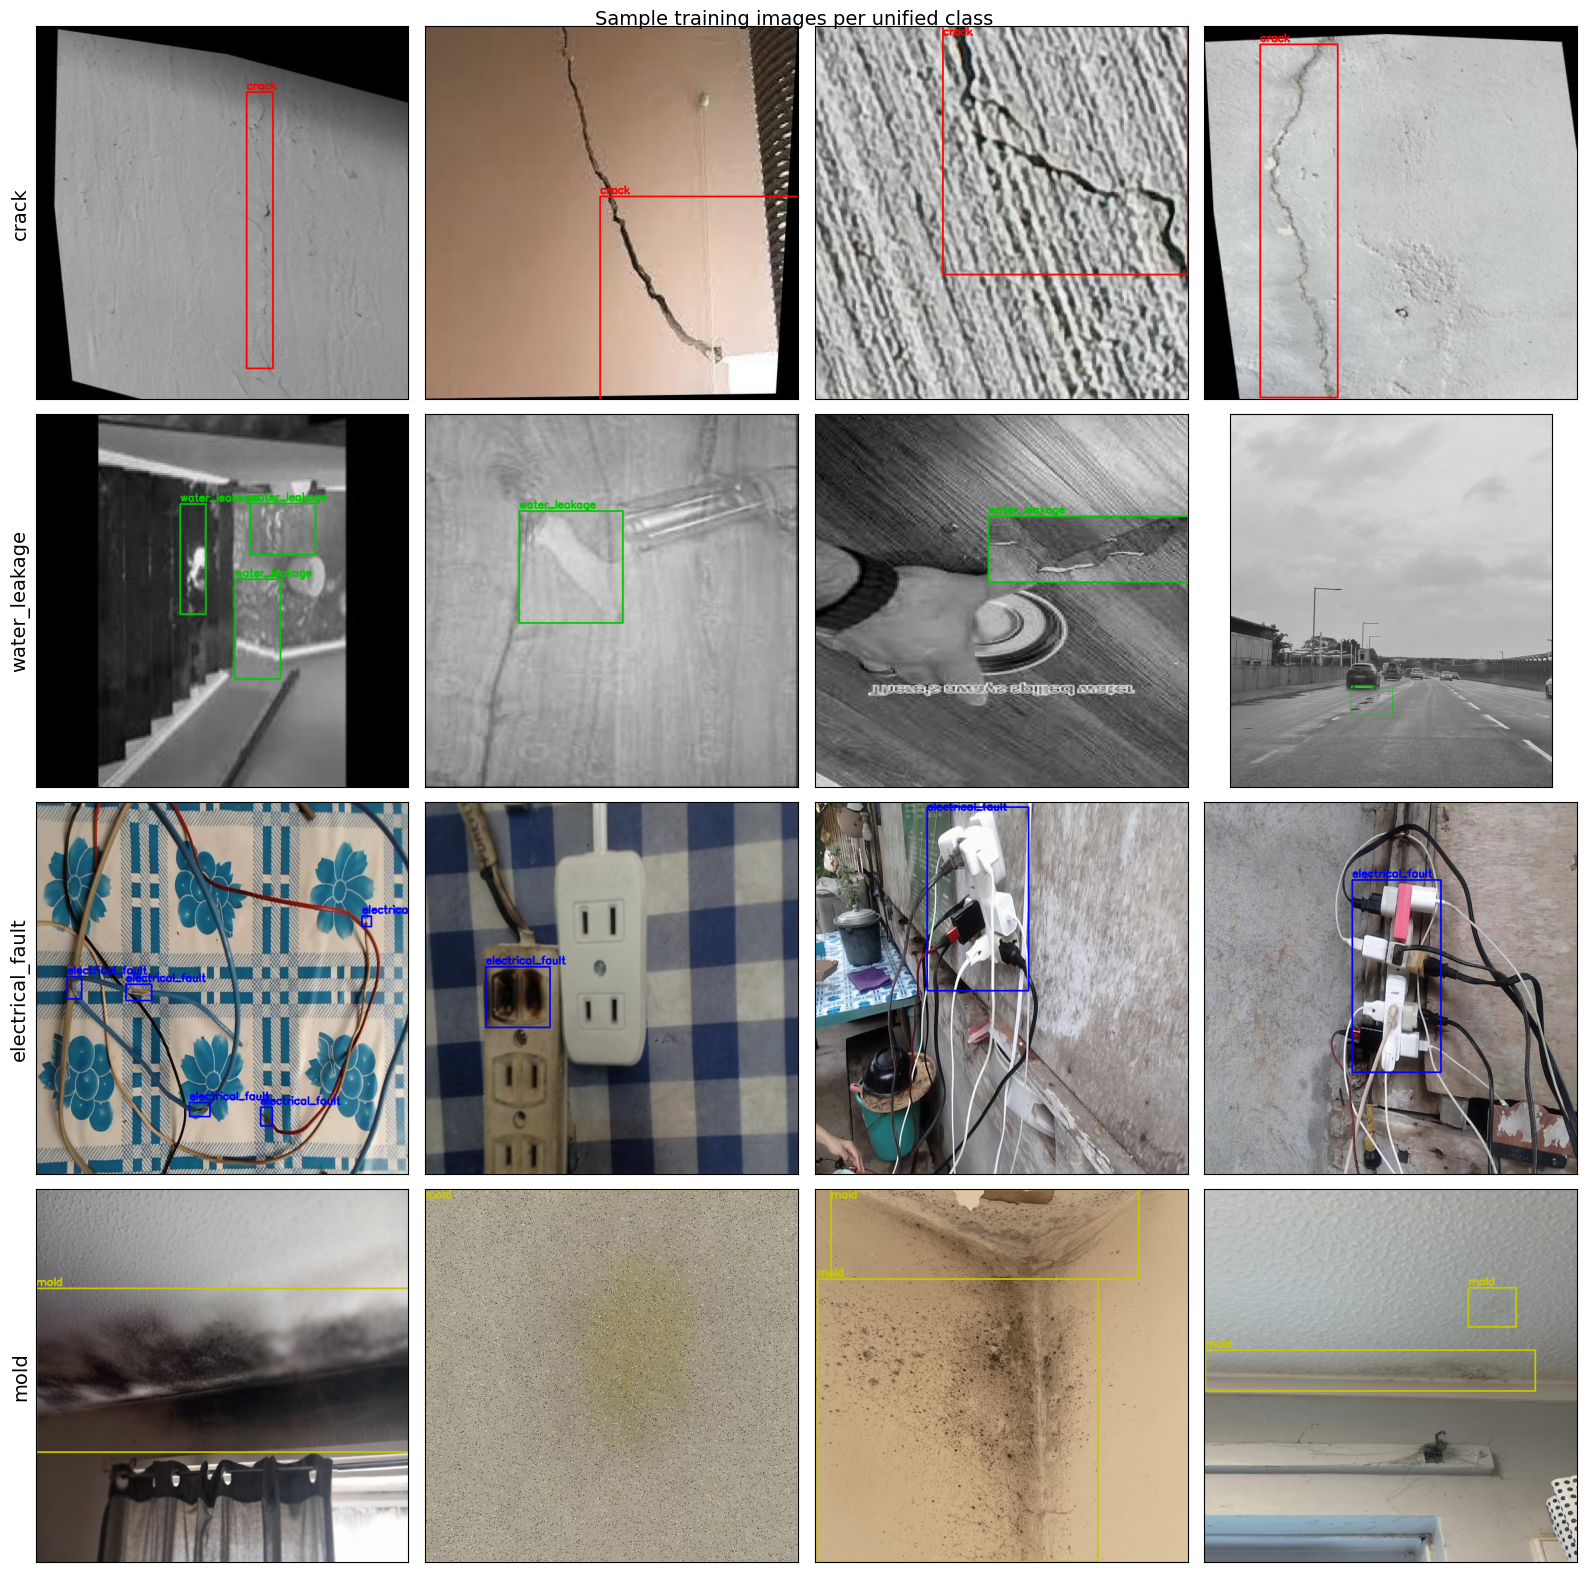

In [22]:
def draw_yolo_boxes(img_bgr, label_path):
    h, w = img_bgr.shape[:2]
    colors = [(0, 0, 255), (0, 200, 0), (255, 0, 0), (0, 200, 200)]
    if not Path(label_path).exists():
        return img_bgr
    with open(label_path) as f:
        for line in f:
            p = line.strip().split()
            if len(p) < 5:
                continue
            cid = int(float(p[0]))
            cx, cy, bw, bh = map(float, p[1:5])
            x1 = int((cx - bw / 2) * w); y1 = int((cy - bh / 2) * h)
            x2 = int((cx + bw / 2) * w); y2 = int((cy + bh / 2) * h)
            cv2.rectangle(img_bgr, (x1, y1), (x2, y2), colors[cid % 4], 2)
            cv2.putText(img_bgr, UNIFIED_CLASSES[cid], (x1, max(y1 - 5, 15)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, colors[cid % 4], 2)
    return img_bgr

# Index train images by which classes they contain.
by_class = defaultdict(list)
for lbl in (UNIFIED_DIR / "labels" / "train").glob("*.txt"):
    classes_present = set()
    with open(lbl) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                classes_present.add(int(float(parts[0])))
    if not classes_present:
        continue
    for ext in (".jpg", ".jpeg", ".png", ".JPG", ".PNG"):
        img_p = UNIFIED_DIR / "images" / "train" / f"{lbl.stem}{ext}"
        if img_p.exists():
            for c in classes_present:
                by_class[c].append((img_p, lbl))
            break

N_COLS = 4
fig, axes = plt.subplots(len(UNIFIED_CLASSES), N_COLS,
                         figsize=(4 * N_COLS, 4 * len(UNIFIED_CLASSES)))
for row, cname in enumerate(UNIFIED_CLASSES):
    cid = CLASS_TO_IDX[cname]
    pool = by_class[cid]
    samples = random.sample(pool, min(N_COLS, len(pool))) if pool else []
    for col in range(N_COLS):
        ax = axes[row, col] if len(UNIFIED_CLASSES) > 1 else axes[col]
        if col < len(samples):
            img_p, lbl_p = samples[col]
            img = cv2.imread(str(img_p))
            img = draw_yolo_boxes(img, lbl_p)
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            ax.text(0.5, 0.5, "no sample", ha="center", va="center")
        if col == 0:
            ax.set_ylabel(cname, fontsize=14)
        ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Sample training images per unified class", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Albumentations augmentation (training data only)

Three augmented copies are generated per training image and saved alongside the originals. Val and test are never touched. Ultralytics' built-in online augmentation (mosaic / mixup / HSV) remains active during training — this is intentional; two-layer aug is standard.

In [23]:
aug = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.4),
        A.HueSaturationValue(p=0.3),
        A.RandomGamma(p=0.3),
        A.OneOf([A.MotionBlur(p=1.0), A.GaussianBlur(p=1.0)], p=0.2),
        A.CLAHE(p=0.2),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.5),
    ],
    bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"], min_visibility=0.3),
)

train_img_dir = UNIFIED_DIR / "images" / "train"
train_lbl_dir = UNIFIED_DIR / "labels" / "train"

# Snapshot originals so re-running this cell doesn't cascade-augment augmentations.
aug_suffixes = tuple(f"_aug{i}" for i in range(1, AUG_MULTIPLIER + 1))
originals = [
    p for p in train_img_dir.iterdir()
    if p.is_file() and not p.stem.endswith(aug_suffixes)
]
print(f"Augmenting {len(originals)} training images x{AUG_MULTIPLIER} ...")

created = 0
for img_path in originals:
    lbl_path = train_lbl_dir / f"{img_path.stem}.txt"
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        continue
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    bboxes, labels = [], []
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    bboxes.append([float(x) for x in parts[1:5]])
                    labels.append(int(float(parts[0])))

    for i in range(1, AUG_MULTIPLIER + 1):
        try:
            out = aug(image=img_rgb, bboxes=bboxes, class_labels=labels)
        except Exception:
            continue
        aug_stem = f"{img_path.stem}_aug{i}"
        aug_bgr = cv2.cvtColor(out["image"], cv2.COLOR_RGB2BGR)
        cv2.imwrite(str(train_img_dir / f"{aug_stem}.jpg"), aug_bgr)
        with open(train_lbl_dir / f"{aug_stem}.txt", "w") as f:
            for c, b in zip(out["class_labels"], out["bboxes"]):
                f.write(f"{c} {' '.join(f'{v:.6f}' for v in b)}\n")
        created += 1

total = len(list(train_img_dir.glob('*')))
print(f"Created {created} augmented samples. Total train images now: {total}.")

ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.


Augmenting 18581 training images x3 ...
Created 47679 augmented samples. Total train images now: 66260.


### 8b. Post-augmentation train class distribution

Train class counts after augmentation: {'crack': 16024, 'water_leakage': 21697, 'electrical_fault': 26617, 'mold': 40807}


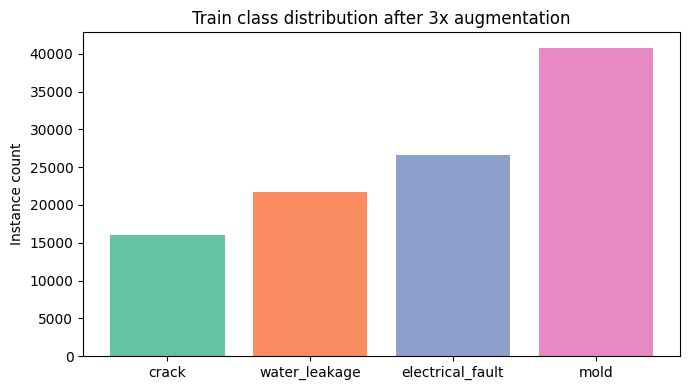

In [27]:
post_counts = count_classes("train")
print(f"Train class counts after augmentation: {post_counts}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(UNIFIED_CLASSES,
       [post_counts[c] for c in UNIFIED_CLASSES],
       color=sns.color_palette("Set2", n_colors=len(UNIFIED_CLASSES)))
ax.set_ylabel("Instance count")
ax.set_title(f"Train class distribution after {AUG_MULTIPLIER}x augmentation")
plt.tight_layout()
plt.show()

## 9. Train YOLO26l for 100 epochs

On a Colab T4, this can take several hours. If the session disconnects, re-run cells 1–2 and then the **resume cell** below (uncomment it).

In [ ]:
model = YOLO("yolo26l.pt")

results = model.train(
    data=str(UNIFIED_DIR / "data.yaml"),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=0,
    workers=24,          # 26 CPUs: 24 dataloader workers, 2 reserved for main + OS
    cache="ram",
    cos_lr=True,
    warmup_epochs=5,
    close_mosaic=20,
    mixup=0.15,
    copy_paste=0.1,
    label_smoothing=0.1,
    multi_scale=0.5,
    patience=30,
    exist_ok=True,
    project=str(RUNS_DIR),
    name="defect_detect",
    seed=SEED,
    plots=True,
)

### Resume training (only if Colab disconnected mid-run)

Uncomment and run this cell instead of the training cell above. Ultralytics will pick up from the last saved epoch.

In [ ]:
# model = YOLO(str(RUNS_DIR / 'defect_detect' / 'weights' / 'last.pt'))
# results = model.train(resume=True)

## 10. Evaluate on the test split

In [ ]:
best_pt = RUNS_DIR / "defect_detect" / "weights" / "best.pt"
model = YOLO(str(best_pt))

metrics = model.val(
    data=str(UNIFIED_DIR / "data.yaml"),
    split="test",
    augment=True,   # TTA: typically +1-2% mAP at no training cost
    plots=True,
)

print(f"\nmAP50:    {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print("\nPer-class AP (mAP50-95):")
for i, cname in enumerate(UNIFIED_CLASSES):
    ap = metrics.box.maps[i] if i < len(metrics.box.maps) else float('nan')
    print(f"    {cname:<20s} {ap:.4f}")

## 11. Qualitative predictions on random test images

In [ ]:
test_images = list((UNIFIED_DIR / "images" / "test").glob("*"))
sample = random.sample(test_images, min(8, len(test_images)))
preds = model.predict(source=[str(p) for p in sample], conf=0.25, imgsz=IMG_SIZE, verbose=False)

rows = 2
cols = max(1, (len(preds) + rows - 1) // rows)
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = np.array(axes).reshape(rows, cols)
for idx in range(rows * cols):
    ax = axes.flat[idx]
    if idx < len(preds):
        plotted = preds[idx].plot()  # BGR
        ax.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    ax.axis("off")
plt.suptitle("YOLO26l predictions on test samples (conf=0.25)", fontsize=14)
plt.tight_layout()
plt.show()

## 12. Download `best.pt`

In [ ]:
best_pt = RUNS_DIR / "defect_detect" / "weights" / "best.pt"
print(f"Best weights: {best_pt}  ({best_pt.stat().st_size / 1e6:.1f} MB)")

# Copy to Lightning's persistent workspace so it survives session end
out = Path("/teamspace/studios/this_studio/best.pt")
shutil.copy2(best_pt, out)
print(f"\nCopied to persistent storage: {out}")
print("\nDownload to your local machine with:")
print("  scp s_01kpxpv15d6sbp8mwsnffw8ed9@ssh.lightning.ai:/teamspace/studios/this_studio/best.pt .")